<!-- SPDX-FileCopyrightText: 2026 Orbital Research Cluster for Celestial Applications (ORCCA) Lab, University of Colorado at Boulder -->
<!-- SPDX-License-Identifier: ISC -->
# OSIRIS-REx Real Data — Single-Pass SRIF Orbit Determination
---
*Scarabaeus OD Framework | Last revised 2026*

## What this notebook covers

A **self-contained walkthrough of sequential orbit determination** using one real OSIRIS-REx DSN tracking pass.  Every step is explained so that a reader unfamiliar with the Scarabaeus API can follow along.

| # | Topic |
|---|-------|
| 1 | Setup — kernels, units, frames, spacecraft model |
| 2 | Load real radiometric data — sequential ranging + Doppler |
| 3 | Propagate nominal trajectory from SPICE truth |
| 4 | Coarse outlier editing with Huber regression + MAD thresholding |
| 5 | SRIF sequential filter |
| 6 | Pre/post-fit residuals and state-error analysis |

## See Also
- [Media Corrections notebook](advanced_RealMSR_MediaCorrections.ipynb) — tropospheric and ramp-table corrections applied here
- [Batch OD notebook](advanced_IdealMSR_BatchOD.ipynb) — batch (LSB / SRIFB) formulation on simulated data

## 1. Setup

Standard scientific stack plus `scarabaeus`, `supplementary` data helper, and `sklearn` for the outlier-rejection step.

In [1]:
import os
from pathlib import Path
import scarabaeus as scb
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn import linear_model
import supplementary as supp

plt.rcParams.update({
    'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 8,
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.35, 'grid.linestyle': '--',
})

## 1.1 — SPICE Kernels, Units, Frames, and Spacecraft

### Output paths
SPK kernels generated by this notebook are written to `supplementary/supp_data/kernels/scenario/` — the same location used by the Ideal-MSR batch OD notebook — and results to `tutorial_results/real_msr_od/`.

### Units and frames
SCB enforces physical units at every operation via `ArrayWUnits`.  `scb.Units.get_units()` returns unit objects; `scb.Frame.generate_common_frames()` returns the four standard frames:

| Frame | Description |
|---|---|
| `J2000` | Earth Mean Equator, J2000.0 — default inertial propagation frame |
| `ITRF93` | Body-fixed Earth frame — used for DSN ground-station positions |
| `ECLIPJ2000` | Mean Ecliptic, J2000.0 |
| `IAUEARTH` | IAU Earth-fixed frame |

### SPICE kernels
`load_kernel_from_mkfile()` furnishes the full OSIRIS-REx kernel set (SPK trajectories, PCK body constants, LSK leap-second, frame kernels) from the supplementary data metakernel.

### Spacecraft
- **`sc_id = -64`** — NAIF ID for OSIRIS-REx.
- **`scft_transpd_delay`** — transponder turnaround delay in Range Units; subtracted when computing theoretical sequential ranging observables.
- `scb.CelestialBody.from_constants("SUN")` — heliocentric central body.

In [2]:
# load tutorial data
data = supp.load_data()

# load kernels
scb.SpiceManager.clear_kernels()
scb.SpiceManager.load_kernel_from_mkfile(data.OREx_real_data_mk.path)

# ── output paths (same convention as advanced_IdealMSR_BatchOD) ──────────────
tut_kernels_path = Path(data.mk.path).parent.parent / 'scenario'
tut_result_path  = Path.cwd() / 'tutorial_results' / 'real_msr_od'
tut_kernels_path.mkdir(parents=True, exist_ok=True)
tut_result_path.mkdir(parents=True, exist_ok=True)

# Generate common frames and units
kg, km, sec, unitless = scb.Units.get_units(["kg", "km", "sec", "unitless"])
(J2000, ITRF93, ECLIPJ2000, IAUEARTH) = scb.Frame.generate_common_frames()

# Scenario parameters
sc_id = -64
scft_transpd_delay = 16529.719234434557

# Spacecraft
Orbiter_mass   = scb.ArrayWUnits(1200.0, kg)
Orbiter_area   = scb.ArrayWUnits(1.2e-05, km**2)
Orbiter_cr_srp = scb.ArrayWUnits(0.8, None)
Orbiter = scb.Spacecraft("Orbiter", sc_id, Orbiter_mass, Orbiter_area, Orbiter_cr_srp)

frame  = J2000
origin = scb.CelestialBody.from_constants("SUN")

SCB supplementary data up to date.


## 2. Load Radiometric Tracking Data and Apply Media Corrections

### Scarabaeus measurement JSON format
Scarabaeus real measurement models expect tracking data in a **predefined JSON format**.  Each file represents one DSN pass and contains a set of top-level keys:

| Key | Content |
|---|---|
| `2W_sranging` | Sequential ranging observable — epoch, value, station SPICE ID, outlier flags |
| `2W_doppler` | Doppler observable — epoch, value, count time, station SPICE ID, outlier flags |
| `aux_SFDU_0` | Uplink carrier ramp table (SFDU record 0) |
| `aux_SFDU_2` / `aux_SFDU_3` | Uplink / downlink zenith-height corrections (SFDU 2 & 3) |
| `aux_SFDU_7` | Ranging modulo, uplink frequency, station calibration delays (SFDU 7) |
| `aux_SFDU_9` | Exciter ramp table — sec, doy, ramp_freq, ramp_rate, ramp_type (SFDU 9) |
| `aux_SFDU_16` | Doppler count time, M₂ turnaround ratio, outlier flags (SFDU 16) |

Converting raw DSN files into this format is handled by **Deep Whale Network (DWN)**, an internal ORCCA tool that is not yet publicly released.

### Tracking observables
Two DSN observable types are loaded from a single tracking JSON file:

| Model class | Observable | Physical quantity |
|---|---|---|
| `SequentialRangingReal` | `2W_sranging` | Round-trip light time → range [RU] |
| `DopplerReal` | `2W_doppler` | Carrier frequency shift → range-rate [Hz] |

### Auxiliary data (`aux_fun`)
`aux_fun()` packages the SFDU ancillary metadata into two dictionaries — one per observable type — consumed by SCB's measurement models:

- **SFDU_7** — ranging modulo, uplink frequency, station calibration delays, RU conversion scalars
- **SFDU_16** — Doppler count time `Tc`, M₂ turnaround ratio
- **SFDU_9** — ramp table (frequency ramps on the uplink exciter)
- **SFDU_2 / SFDU_3** — tropospheric zenith-height corrections

The Doppler uplink-frequency fields (`ul_freq`, etc.) are filled with the max-unique value from the ranging records because SFDU_7 is synchronised with ranging epochs, not Doppler epochs.

### Media corrections
`scb.MediaCorrections` attaches atmospheric corrections directly to each measurement model.  The seasonal tropospheric file is loaded at construction; the non-seasonal file (year/day specific) is resolved by `find_tro_metadata()` against the pass date.

In [3]:
def aux_fun(trk_data):
    # Generate the sranging auxiliary data dictionary
    sranging_aux_data = {
        #
        # Sranging auxiliary data (from 2W_sranging, SFDU_7)
        #
        "RU": (((np.array(trk_data["aux_SFDU_7"]["exc_scalar_den"]) / np.array(trk_data["aux_SFDU_7"]["exc_scalar_num"])) / 16 ) ** -1).tolist(),
        "M": trk_data["aux_SFDU_7"]["rng_modulo"],
        "M2_num": trk_data["aux_SFDU_16"]["M2_num"],
        "M2_den": trk_data["aux_SFDU_16"]["M2_den"],
        "rng_type": trk_data["aux_SFDU_7"]["rng_type"],
        "outlier_flag_sranging": trk_data["aux_SFDU_7"]["outlier_flag"],
        "year_SFDU7": trk_data["aux_SFDU_7"]["year"],
        "doy_SFDU7": trk_data["aux_SFDU_7"]["doy"],
        "sec_SFDU7": trk_data["aux_SFDU_7"]["sec"],
        #
        # Delays auxiliary data (from 2W_sranging, SFDU_7)
        #
        "ul_freq": trk_data["aux_SFDU_7"]["ul_freq"],
        "ul_zheight_corr": trk_data["aux_SFDU_2"]["ul_zheight_corr"],
        "dl_zheight_corr": trk_data["aux_SFDU_3"]["dl_zheight_corr"],
        "scft_transpd_delay": scft_transpd_delay, # [RU]  
        "scft_transpd_delay_s": scft_transpd_delay / ((221.0 / (749.0 * 2.0)) * 8445.767679 * 1e6), # [s] 
        "transmit_time_tag_delay": trk_data["2W_doppler"]["transmit_time_tag_delay"],
        "rcv_time_tag_delay": trk_data["2W_doppler"]["rcv_time_tag_delay"],
        "array_delay": trk_data["2W_doppler"]["array_delay"],
        "ul_stn_cal": trk_data["aux_SFDU_7"]["ul_stn_cal"],
        "dl_stn_cal": trk_data["aux_SFDU_7"]["dl_stn_cal"],
        "exc_scalar_num": trk_data["aux_SFDU_7"]["exc_scalar_num"],
        "exc_scalar_den": trk_data["aux_SFDU_7"]["exc_scalar_den"],
        #
        # Ramp table auxiliary data (from SFDU_9)
        #
        "ramp_sec": trk_data["aux_SFDU_9"]["sec"],
        "ramp_day": trk_data["aux_SFDU_9"]["doy"],
        "ramp_freq": trk_data["aux_SFDU_9"]["ramp_freq"],
        "ramp_rate": trk_data["aux_SFDU_9"]["ramp_rate"],
        "ramp_type": trk_data["aux_SFDU_9"]["ramp_type"],
    }
    Doppler_aux_data = {
        #
        # Doppler auxiliary data (from 2W_doppler, SFDU_16)
        #
        "Tc": trk_data["aux_SFDU_16"]["Tc"],
        "M2_num": trk_data["aux_SFDU_16"]["M2_num"],
        "M2_den": trk_data["aux_SFDU_16"]["M2_den"],
        "outlier_flag_doppler": trk_data["aux_SFDU_16"]["outlier_flag"],
        "year_SFDU16": trk_data["aux_SFDU_16"]["year"],
        "doy_SFDU16": trk_data["aux_SFDU_16"]["doy"],
        "sec_SFDU16": trk_data["aux_SFDU_16"]["sec"],
        #
        # Delays auxiliary data (from 2W_doppler, SFDU_16)
        #
        "ul_zheight_corr": trk_data["aux_SFDU_2"]["ul_zheight_corr"],
        "dl_zheight_corr": trk_data["aux_SFDU_3"]["dl_zheight_corr"],
        "scft_transpd_delay": scft_transpd_delay, # [RU]  
        "scft_transpd_delay_s": scft_transpd_delay / ((221.0 / (749.0 * 2.0)) * 8445.767679 * 1e6), # [s] 
        "transmit_time_tag_delay": trk_data["2W_doppler"]["transmit_time_tag_delay"],
        "rcv_time_tag_delay": trk_data["2W_doppler"]["rcv_time_tag_delay"],
        "array_delay": trk_data["2W_doppler"]["array_delay"],
        #
        # Method (1) - Take these values from 2W_sranging and aux_SFDU_7, just max-unique, since its asynch with Doppler time
        #
        "ul_freq":       (np.array(trk_data["aux_SFDU_2"]["ul_zheight_corr"]) * 0).tolist() + np.max(np.unique(trk_data["aux_SFDU_7"]["ul_freq"])),
        "ul_stn_cal":    (np.array(trk_data["aux_SFDU_2"]["ul_zheight_corr"]) * 0).tolist() + np.max(np.unique(trk_data["aux_SFDU_7"]["ul_stn_cal"])),
        "dl_stn_cal":    (np.array(trk_data["aux_SFDU_2"]["ul_zheight_corr"]) * 0).tolist() + np.max(np.unique(trk_data["aux_SFDU_7"]["dl_stn_cal"])),
        "exc_scalar_num":(np.array(trk_data["aux_SFDU_2"]["ul_zheight_corr"]) * 0).tolist() + np.max(np.unique(trk_data["aux_SFDU_7"]["exc_scalar_num"])),
        "exc_scalar_den":(np.array(trk_data["aux_SFDU_2"]["ul_zheight_corr"]) * 0).tolist() + np.max(np.unique(trk_data["aux_SFDU_7"]["exc_scalar_den"])),
        "RU": 0.14753004005340453,
        #
        # Ramp table auxiliary data (from SFDU_9)
        #
        "ramp_sec": trk_data["aux_SFDU_9"]["sec"],
        "ramp_day": trk_data["aux_SFDU_9"]["doy"],
        "ramp_freq": trk_data["aux_SFDU_9"]["ramp_freq"],
        "ramp_rate": trk_data["aux_SFDU_9"]["ramp_rate"],
        "ramp_type": trk_data["aux_SFDU_9"]["ramp_type"],
    }
    return sranging_aux_data, Doppler_aux_data

def add_media_to_meas_model(obs_quantities, meas_model, media_correction_object):
    year_pass_media, day_pass_media, _ = scb.SpiceManager.et2YDS([obs_quantities[0].times.values[0]])
    metadata_tropo = scb.MediaCorrections.find_tro_metadata(tropo_file_bucket, year_pass_media[0], day_pass_media[0])
    metadata_iono = scb.MediaCorrections.find_ion_metadata(iono_file_bucket, year_pass_media[0], day_pass_media[0])
    if metadata_tropo:
        media_correction_object.tropo_non_seasonal_file_path = os.path.join(tropo_file_bucket, metadata_tropo['file'])
    if metadata_iono:
        media_correction_object.iono_file_path = os.path.join(iono_file_bucket, metadata_iono['file'])
    meas_model.media_corrections = media_correction_object
    return meas_model

# Setup tropo correction filepaths
tropo_seasonal_file_path = data.tropo_seasonal_new.path
trk_file_path = data.trk_file.path
tropo_file_bucket = os.path.dirname(data.tropo_nonseasonal.path)
iono_file_bucket  = os.path.dirname(data.tropo_nonseasonal.path)

# Load the radiometric data 
meas_dict_list = []

trk_data = scb.Utils.load_json(trk_file_path)
aux_data_sr, aux_data_dop = aux_fun(trk_data)
meas_dict_list.append(aux_data_sr)
meas_dict_list.append(aux_data_dop)

# Get the ground station
GS1_name = "DSS-" + str(trk_data["2W_doppler"]["spice_id"][0])
GS1 = scb.GroundStation(GS1_name)

sranging_sigma = scb.ArrayWUnits(1e1, km / km)
doppler_sigma  = scb.ArrayWUnits(1e-3, 1 / sec)

# Create measurement models
sranging_model = scb.SequentialRangingReal("GS1 Real Range", GS1, sigma=sranging_sigma,
                                           meas_bias=0.0, computed_measurements_dict=meas_dict_list[0])
doppler_model  = scb.DopplerReal("GS1 Real Range Rate", GS1, sigma=doppler_sigma,
                                  meas_bias=0.0, computed_measurements_dict=meas_dict_list[1])

# Create media correction objects 
mc_sranging = scb.MediaCorrections(name="GS1 Media Corrections srang", instrument=GS1,
                                   tropo_seasonal_file_path=tropo_seasonal_file_path)
mc_doppler  = scb.MediaCorrections(name="GS1 Media Corrections doppler", instrument=GS1,
                                   tropo_seasonal_file_path=tropo_seasonal_file_path)

# Generate observed quantities
sr_obs     = sranging_model.observed_measurements(trk_file_path, meas_name="2W_sranging", units=km / km)
doppler_obs = doppler_model.observed_measurements(trk_file_path, meas_name="2W_doppler",  units=1 / sec)

# Add media correction to measurement models 
sranging_model = add_media_to_meas_model(sr_obs, sranging_model, mc_sranging)
doppler_model  = add_media_to_meas_model(doppler_obs, doppler_model, mc_doppler)

# Organize products for processing 
obs_quantities_list = [sr_obs, doppler_obs]
model_list          = [sranging_model, doppler_model]
meas_type_list      = ['range', 'range_rate']
file_label_list     = ["real_range", "real_range_rate"]

## 3. Trajectory Propagation

The scenario time window is built directly from the observation epochs with a 1-hour pad on each side.

### Force model
The *truth* propagation uses:
- **Point-mass gravity** from the Sun (primary body)
- **Third-body perturbations** from all eight planets + Pluto (barycenter IDs)
- **Cannonball SRP** — spherical spacecraft, constant reflectivity `C_r = 0.8`

### SPK output
After propagation, `Trajectory.write_to_spk()` writes a binary SPICE SPK kernel to `tut_kernels_path`.  This kernel serves as the *truth reference* against which the filter solution is compared in Section 6.

In [4]:
# Get the time period for the scenario 
et_min = 1e34
et_max = 0.0
for obs in obs_quantities_list:
    et = obs[0]
    et_min = np.min([np.min(et.times.values), et_min])
    et_max = np.max([np.max(et.times.values), et_max])

all_et_obs        = np.concatenate([obs[0].times.values for obs in obs_quantities_list])
all_et_obs_unique = np.sort(np.unique(all_et_obs))

et_min_obs, et_max_obs = all_et_obs_unique[0], all_et_obs_unique[-1]
et_padded = np.linspace(et_min_obs - 3600, et_max_obs + 3600, int(1e6))

et_start = et_padded[0]
et_end   = et_padded[-1]

print('Start time (UTC): ', scb.SpiceManager.et2utc(et_start))
print('End time   (UTC): ', scb.SpiceManager.et2utc(et_end))

epoch_array     = scb.EpochArray(et_padded, sys="TDB")
epoch_array_obs = scb.EpochArray(all_et_obs_unique, sys="TDB")

# Initial state from SPICE
sc_state_0 = scb.SpiceManager.get_state(str(sc_id), et_start, J2000, origin).values
pos_0 = scb.ArrayWFrame(sc_state_0[0:3], km, J2000)
vel_0 = scb.ArrayWFrame(sc_state_0[3:6], km / sec, J2000)

state_vector = scb.StateArray(
    epoch=epoch_array[0], origin=origin,
    state=scb.StateDefinition.from_components([
        ("position", 3, "estimated", "dynamic", Orbiter, pos_0),
        ("velocity", 3, "estimated", "dynamic", Orbiter, vel_0),
    ])
)

# True trajectory SPK
orbiter_true_spk = tut_kernels_path / "orex_orbiter_true.bsp"
if orbiter_true_spk.exists(): orbiter_true_spk.unlink()

third_bodies = [
    "MERCURYBARYCENTER", "VENUSBARYCENTER", "EARTHBARYCENTER", "MARSBARYCENTER",
    "JUPITERBARYCENTER", "SATURNBARYCENTER", "URANUSBARYCENTER",
    "NEPTUNEBARYCENTER", "PLUTOBARYCENTER",
]

force_model = scb.ForceModelTranslation(primary_body=Orbiter,
                                         third_bodies=third_bodies,
                                         cannonball_SRP=True)

prop = scb.Propagator(primary_body=Orbiter, state_vector=state_vector,
                      tspan=epoch_array, force_models=force_model)
prop.propagate()

orbiter_traj = scb.Trajectory(state_array=prop.propagated_state_array)
orbiter_traj.write_to_spk(str(orbiter_true_spk))

Start time (UTC):  2018-06-08T04:55:02.999998
End time   (UTC):  2018-06-08T11:28:53.000001



                            Starting propagation...                             


Integrating:   0%|                                                       | 0.00/23630.00 s [00:00<?]

Integrating:   0%|                                                       | 0.00/23630.00 s [00:00<?]

Integrating:   0%|                                                 | 0.01/23630.00 s [00:00<6:30:18]

...

Integrating: 100%|███████████████████████████████████████████████| 23630.00/23630.00 s [00:00<00:00]

Integrating: 100%|███████████████████████████████████████████████| 23630.00/23630.00 s [00:00<00:00]

Integrating: 100%|███████████████████████████████████████████████| 23630.00/23630.00 s [00:00<00:00]

Integrating: 100%|███████████████████████████████████████████████| 23630.00/23630.00 s [00:00<00:00]


 =================== DOP853 integration complete. ==================
Propagation complete.


## 4. Coarse Outlier Editing

Before the measurements are handed to the sequential filter, gross outliers must be removed.  A single bad point can corrupt the estimate consistency or cause divergence.

### Why Huber regression?
Ordinary least-squares trend fits are pulled toward outliers, defeating the purpose.  **Huber regression** down-weights large residuals during the fit, producing a detrended residual sequence that is insensitive to the very points we want to flag.

### MAD thresholding
Outliers are identified via the **Median Absolute Deviation**:

$$\text{MAD} = \text{median}\!\left(|r_i - \text{median}(r)|\right)$$

Any observation with a detrended residual exceeding `mad_threshold × MAD` is discarded.  The thresholds here (`thresh_sr = 5`, `thresh_dop = 30`) are deliberately loose — this is a *coarse* pass, not the fine editing the filter applies measurement-by-measurement.

In [5]:
def clean_obs_sr(obs, model, target, frame, aux_data, mad_threshold):
    _, _, _, computed_obs = model.computed_measurements(
        target=target, epoch_array=obs[0], frame=frame, noisy=False, eps_override=aux_data,
    )
    obs_vals     = obs[2].quantity.values
    computed_vals = computed_obs.quantity.values
    resids = obs_vals - computed_vals

    x_huber = obs[0].times.values - np.min(obs[0].times.values)   # normalised for numerical stability
    clf = linear_model.HuberRegressor()
    clf.fit(x_huber[:, np.newaxis], resids)
    resids_huber = resids - clf.predict(x_huber[:, np.newaxis])

    mad  = np.median(np.abs(resids_huber - np.median(resids_huber)))
    mask = np.abs(resids_huber) <= mad_threshold * mad

    obs_clean = (
        scb.EpochArray(obs[0].times.values[mask], sys="TDB"),
        obs[1][mask],
        scb.ArrayWFrame(obs[2].quantity.values[mask], km / km, frame),
        obs[3][mask],
    )
    aux_data_clean = aux_data.copy()
    for kk in aux_data_clean:
        if isinstance(aux_data_clean[kk], list) and len(aux_data_clean[kk]) == len(mask):
            aux_data_clean[kk] = np.array(aux_data_clean[kk])[mask].tolist()
    return obs_clean, aux_data_clean

def clean_obs_dop(obs, model, target, frame, aux_data, mad_threshold):
    _, _, _, computed_obs = model.computed_measurements(
        target=target, epoch_array=obs[0], frame=frame, noisy=False, eps_override=aux_data,
    )
    obs_vals      = obs[2].quantity.values
    computed_vals = computed_obs.quantity.values
    resids = obs_vals - computed_vals

    x_huber = obs[0].times.values - np.min(obs[0].times.values)   # normalised for numerical stability
    clf = linear_model.HuberRegressor()
    clf.fit(x_huber[:, np.newaxis], resids)
    resids_huber = resids - clf.predict(x_huber[:, np.newaxis])

    mad  = np.median(np.abs(resids_huber - np.median(resids_huber)))
    mask = np.abs(resids_huber) <= mad_threshold * mad

    obs_clean = (
        scb.EpochArray(obs[0].times.values[mask], sys="TDB"),
        obs[1][mask],
        scb.ArrayWFrame(obs[2].quantity.values[mask], 1 / sec, frame),
        obs[3][mask],
    )
    aux_data_clean = aux_data.copy()
    for kk in aux_data_clean:
        if isinstance(aux_data_clean[kk], list) and len(aux_data_clean[kk]) == len(mask):
            aux_data_clean[kk] = np.array(aux_data_clean[kk])[mask].tolist()
    return obs_clean, aux_data_clean


thresh_sr = 5.0
thresh_dop = 30.0

sr_obs_1, aux_data_sr_1 = clean_obs_sr(sr_obs, sranging_model, Orbiter, frame, meas_dict_list[0], thresh_sr)
doppler_obs_1, aux_data_doppler_1 = clean_obs_dop(doppler_obs, doppler_model, Orbiter, frame, meas_dict_list[1], thresh_dop)

meas_dict_list[0] = aux_data_sr_1
meas_dict_list[1] = aux_data_doppler_1

sranging_sigma = scb.ArrayWUnits(0.5, km/km)
doppler_sigma  = scb.ArrayWUnits(0.001, 1 / sec)

sranging_model_1 = scb.SequentialRangingReal("GS1 Real Range", GS1, sigma=sranging_sigma,
                                              meas_bias=0.0, computed_measurements_dict=meas_dict_list[0])
doppler_model_1  = scb.DopplerReal("GS1 Real Range Rate", GS1, sigma=doppler_sigma,
                                    meas_bias=0.0, computed_measurements_dict=meas_dict_list[1])

mc_sranging_1 = scb.MediaCorrections(name="GS1 Media Corrections srang", instrument=GS1,
                                     tropo_seasonal_file_path=tropo_seasonal_file_path)
mc_doppler_1  = scb.MediaCorrections(name="GS1 Media Corrections srang", instrument=GS1,
                                     tropo_seasonal_file_path=tropo_seasonal_file_path)

sranging_model_1 = add_media_to_meas_model(sr_obs_1, sranging_model_1, mc_sranging_1)
doppler_model_1  = add_media_to_meas_model(doppler_obs_1, doppler_model_1, mc_doppler_1)

obs_quantities_list = [sr_obs_1, doppler_obs_1]
model_list          = [sranging_model_1, doppler_model_1]
meas_type_list      = ["range", "rangerate"]
file_label_list     = ["real_range", "real_range_rate"]


Generating computed measurements...


2W Sequential Ranging:   0%|                                                    | 0/99 obs [00:00<?]

2W Sequential Ranging:   1%|▍                                               | 1/99 obs [00:00<00:01]

2W Sequential Ranging:   2%|▉                                               | 2/99 obs [00:00<00:01]

2W Sequential Ranging:   3%|█▍                                              | 3/99 obs [00:00<00:01]

...

2W Doppler: 100%|███████████████████████████████████████████████████████▋| 216/217 obs [00:01<00:00]

2W Doppler: 100%|████████████████████████████████████████████████████████| 217/217 obs [00:01<00:00]

2W Doppler: 100%|████████████████████████████████████████████████████████| 217/217 obs [00:01<00:00]

2W Doppler: 100%|████████████████████████████████████████████████████████| 217/217 obs [00:01<00:00]

Applying media corrections: tropo (217/217 measurements)


## 5. SRIF Sequential Filter

### Theory
The **Square Root Information Filter (SRIF)** propagates the square-root information matrix $\bar{R}$ instead of the covariance $P$ directly.  This avoids the positive-definiteness degradation that can occur in standard Kalman implementations when process noise is small. 

### Reference trajectory
The filter estimates **deviations** from a reference trajectory, not the absolute state.  A separate `Spacecraft` object (`Orbiter_ref`, SPICE ID `-1001`) is created so its SPK can be written without overwriting the truth kernel.  Initial perturbations are set to zero — the filter starts from the SPICE truth, a useful baseline for validating convergence.

### Covariance and process noise

| Parameter | Value | Meaning |
|---|---|---|
| Position σ | 1000 km | Conservative |
| Velocity σ | 1×10⁻³ km/s | Conservative |
| Q (SNC) | 1×10⁻¹¹ km²/s⁴ | Unmodelled acceleration power spectral density |

`scb.ProcessNoiseSettings(type='SNC')` applies **Stochastic Noise Compensation** — a continuous-time random acceleration model in Cartesian directions.

In [6]:
# Filter parameters
filter_pos_sigma     = 1000 # [km]
filter_vel_sigma     = 1e-3 # [km/s]
filter_process_noise = 5 * 1e-10 # [km/s^2]
filter_convergence_thr = 100

# Reference spacecraft (distinct SPICE ID)
Orbiter_ref = scb.Spacecraft("orbiter_ref_it1", -1001, Orbiter_mass, Orbiter_area, Orbiter_cr_srp)
Orbiter_ref.add_instrument([scb.Antenna("Antenna_for_radiometric", spice_id=-1000)])

pos_ref = scb.ArrayWFrame(pos_0.quantity, frame)
vel_ref = scb.ArrayWFrame(vel_0.quantity, frame)

state_vector_pert = scb.StateArray(
    epoch=epoch_array[0], origin=origin,
    state=scb.StateDefinition.from_components([
        ("position", 3, "estimated", "dynamic", Orbiter_ref, pos_ref),
        ("velocity", 3, "estimated", "dynamic", Orbiter_ref, vel_ref),
    ])
)

# Reference trajectory SPK paths
ref_spk_it1   = tut_kernels_path / "orex_orbiter_ref_orex.bsp"
ref_spk_final = tut_kernels_path / "orex_orbiter_ref.bsp"
if ref_spk_it1.exists():   ref_spk_it1.unlink()
if ref_spk_final.exists(): ref_spk_final.unlink()

force_model_ref = scb.ForceModelTranslation(primary_body=Orbiter_ref,
                                                   third_bodies=third_bodies,
                                                   cannonball_SRP=True)
prop_ref = scb.Propagator(primary_body=Orbiter_ref,
                                state_vector=state_vector_pert,
                                tspan=epoch_array,
                                force_models=force_model_ref)

# Covariance P
state_covariance = scb.CovarianceMatrix(
    [scb.ArrayWUnits(filter_pos_sigma, km)] * 3 + [scb.ArrayWUnits(filter_vel_sigma, km / sec)] * 3,
    epoch_array[0], from_list=True
)

# Process noise Q
Q_diag = scb.ArrayWUnits(filter_process_noise, km**2 * sec**-4)
Q_cont = scb.CovarianceMatrix([Q_diag, Q_diag, Q_diag], epoch_array[0], from_list=True)

# ── MeasurementSpec (same API as advanced_IdealMSR_BatchOD) ──────────────────
measurements = scb.MeasurementSpec.many(
    scb.MeasurementSpec(model=model_list[0], observed_meas=obs_quantities_list[0],
                        dataset_name=model_list[0].name, file_label=file_label_list[0]),
    scb.MeasurementSpec(model=model_list[1], observed_meas=obs_quantities_list[1],
                        dataset_name=model_list[1].name, file_label=file_label_list[1]),
)

settings = scb.FilterSettings(
    initial_covariance=state_covariance,
    process_noise=scb.ProcessNoiseSettings(type='SNC', Q_cont=Q_cont),
    output=scb.OutputSettings(metadata={'version': '1.0', 'producer': 'ops_team'}),
)

srif_it1 = scb.SRIF(
    propagator   = prop_ref,
    settings     = settings,
    measurements = measurements,
    traj_name    = "orex_orbiter_ref_orex.bsp",
    traj_dir     = str(tut_kernels_path),
)

solution, n_iters, converged = srif_it1.fit(
    max_iterations=1,
    convergence_threshold=filter_convergence_thr,
    verbose=True,
    traj_name = "orex_orbiter_ref.bsp",
    traj_dir  = str(tut_kernels_path),
)


                            Starting propagation...                             


Integrating:   0%|                                                       | 0.00/23630.00 s [00:00<?]

Integrating:   0%|                                                       | 0.00/23630.00 s [00:00<?]

Integrating:   0%|                                                 | 0.01/23630.00 s [00:00<4:24:26]

Integrating:   0%|                                                       | 0.00/23630.00 s [00:00<?]

...

2W Doppler:  99%|███████████████████████████████████████████████████████▋| 170/171 obs [00:00<00:00]

2W Doppler: 100%|████████████████████████████████████████████████████████| 171/171 obs [00:00<00:00]

2W Doppler: 100%|████████████████████████████████████████████████████████| 171/171 obs [00:00<00:00]

2W Doppler: 100%|████████████████████████████████████████████████████████| 171/171 obs [00:00<00:00]

Applying media corrections: tropo (171/171 measurements)

           Generating _partials for the dataset "GS1 Real Range Rate"           

Initializing Sequence Square Root Information Filter (SRIF)
Process Noise Model: SNC

STARTING ITERATIVE ORBIT DETERMINATION
Max iterations: 1
Convergence threshold: 1.00e+02


ITERATION 1
[581713312.91 TDB |   0.0%] ‖prefit‖=1.9236e-03   ‖postfit‖=3.3454e-12   tr(P)=3.0001e+06   ⟨σ⟩=1.00e-03
[581713372.90 TDB |   0.5%] ‖prefit‖=1.9655e-03   ‖postfit‖=2.2502e-08   tr(P)=3.0001e+06   ⟨σ⟩=1.00e-03
[581713432.90 TDB |   1.0%] ‖prefit‖=1.8978e-04   ‖postfit‖=9.5224e-07   tr(P)=3.0001e+06   ⟨σ⟩=1.00e-03
[581713467.90 TDB |   1.3%] ‖prefit‖=1.2315e+04   ‖postfit‖=6.3665e-11   tr(P)=2.0001e+06   ⟨σ⟩=5.00e-01
[581713492.90 TDB |   1.5%] ‖prefit‖=2.8067e-03   ‖postfit‖=9.5530e-06   tr(P)=2.0001e+06   ⟨σ⟩=1.00e-03
[581713591.90 TDB |   2.3%] ‖prefit‖=1.2315e+04   ‖postfit‖=3.1373e-05   tr(P)=1.0014e+06   ⟨σ⟩=5.00e-01
[581713612.90 TDB |   2.4%] ‖prefit‖=3.27

## 6. Results

### Pre- and post-fit residuals
**Pre-fit residuals** are `observed − computed` before each measurement update, reflecting how well the reference trajectory predicts the data.  **Post-fit residuals** are recomputed after the state update — a well-converged filter produces smaller, randomly distributed post-fits with no systematic trends.

### State errors vs. 3σ covariance
Because the initial perturbation is zero, `solution.deviation_est` equals the true state error (truth − estimate).  Plotting the error norm alongside the 3σ bound (from the diagonal blocks of the estimated covariance) shows whether the filter is **consistent** — errors should stay inside the envelope.

/var/folders/_q/_0gmy5p50pbf60yk0vzw402c0000gp/T/ipykernel_67629/3333770580.py:41: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.tight_layout(); plt.show()
/Users/zael5647/scarabaeus/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  fig.canvas.print_figure(bytes_io, **kw)


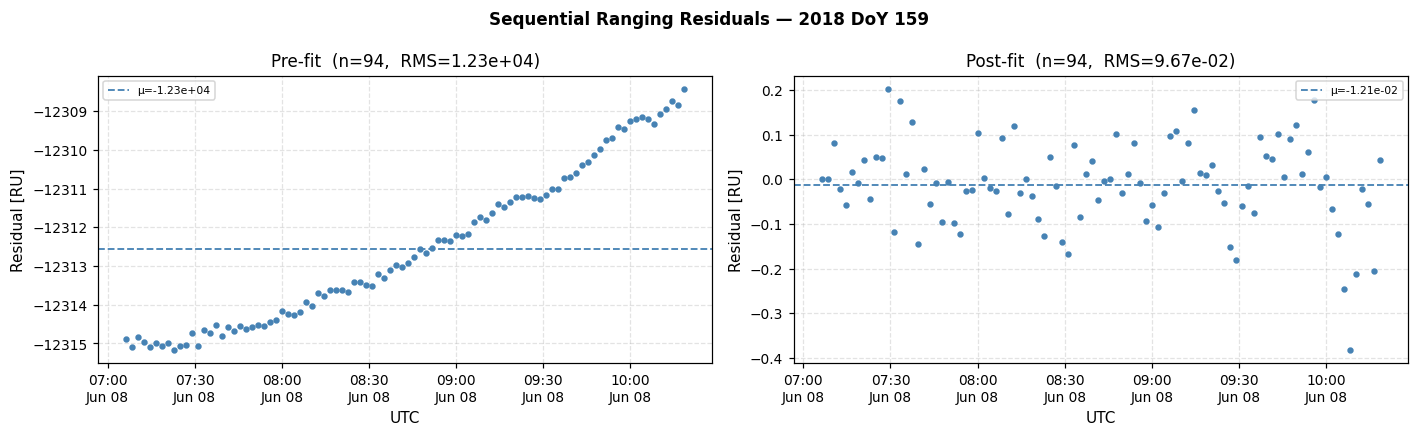

/var/folders/_q/_0gmy5p50pbf60yk0vzw402c0000gp/T/ipykernel_67629/3333770580.py:48: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.tight_layout(); plt.show()


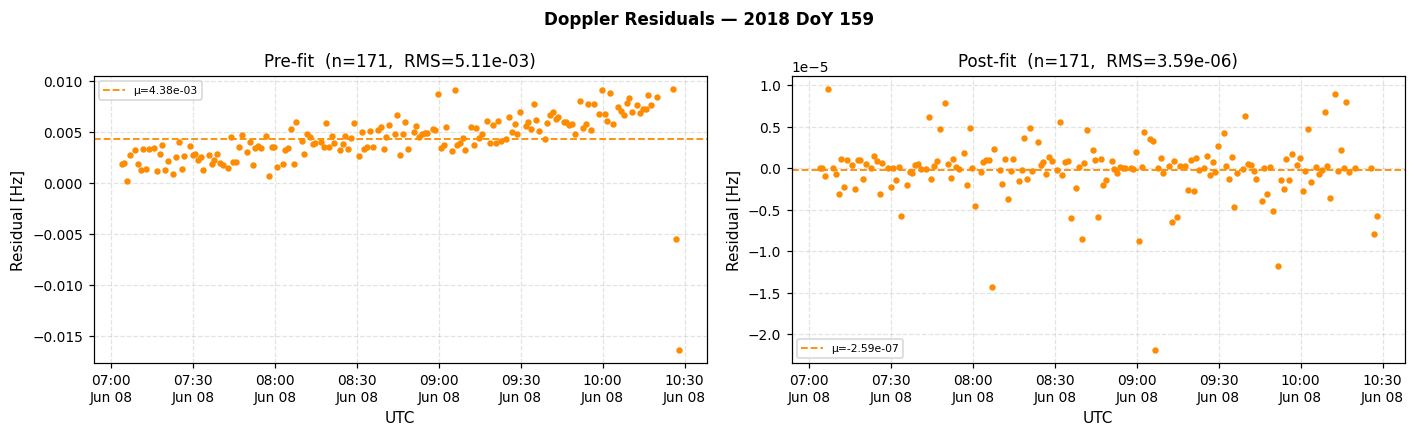

/var/folders/_q/_0gmy5p50pbf60yk0vzw402c0000gp/T/ipykernel_67629/3333770580.py:97: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.tight_layout()


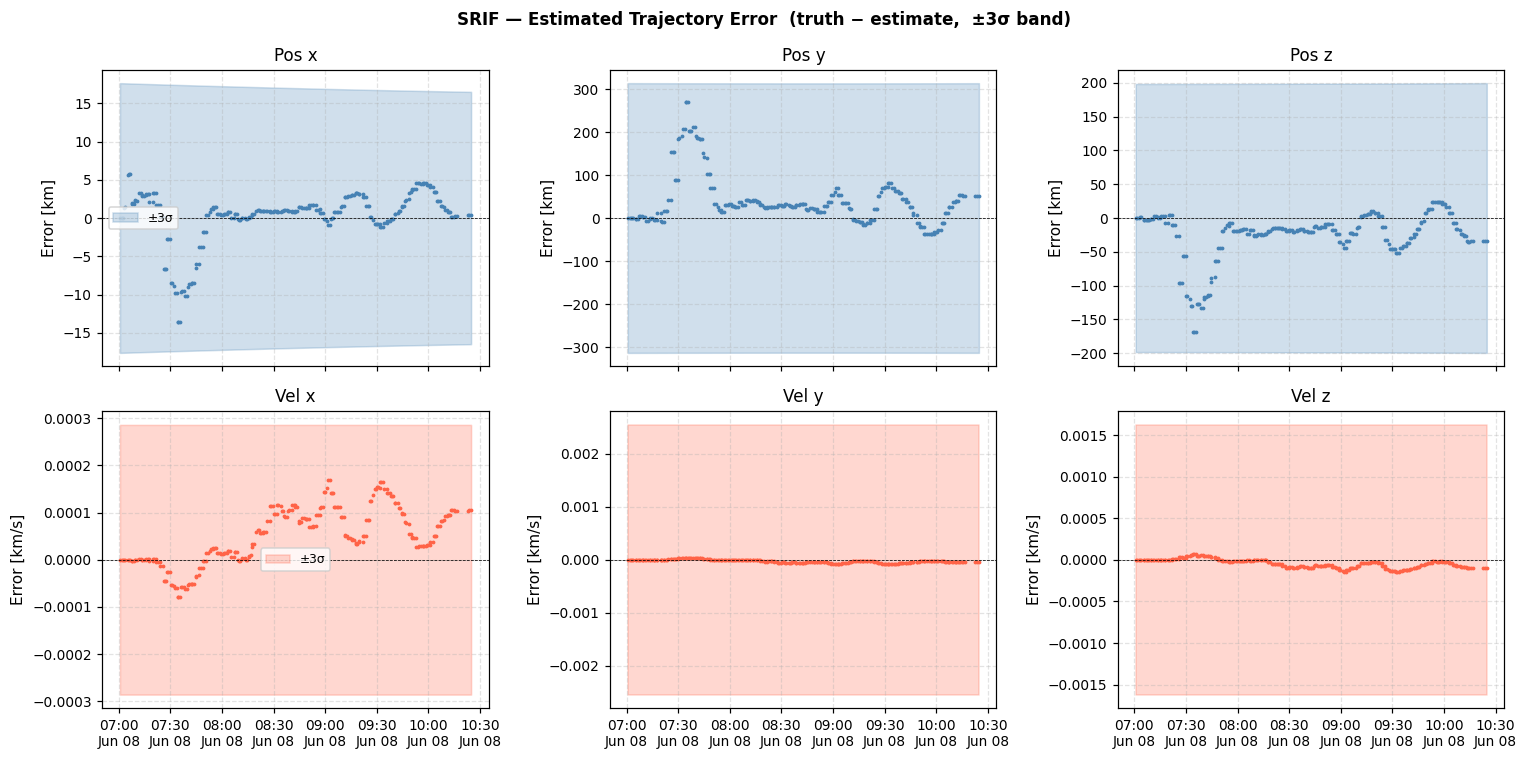

In [7]:
import datetime

def et_to_utc(et_vals):
    return [datetime.datetime.fromisoformat(str(scb.SpiceManager.et2utc(et))[:19])
            for et in et_vals]

def fmt_cal(ax):
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4, maxticks=8))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M\n%b %d"))

# ── residual arrays ───────────────────────────────────────────────────────────
dataset_sr  = list(solution.prefits.keys())[0]
dataset_dop = list(solution.prefits.keys())[1]

pre_sr   = np.array(solution.prefits[dataset_sr])[:, 0]
post_sr  = np.array(solution.postfits[dataset_sr])[:, 0]
pre_dop  = np.array(solution.prefits[dataset_dop])[:, 0]
post_dop = np.array(solution.postfits[dataset_dop])[:, 0]

t_sr_utc  = et_to_utc(sr_obs_1[0].times.values)
t_dop_utc = et_to_utc(doppler_obs_1[0].times.values)

SR_C, DOP_C = "steelblue", "darkorange"

def _scatter_panel(ax, t_utc, data, color, title, ylabel):
    mu  = np.mean(data)
    rms = np.sqrt(np.mean(data**2))
    ax.scatter(t_utc[:len(data)], data, s=10, color=color, zorder=3)
    ax.axhline(mu, color=color, lw=1.2, ls='--', label=f'μ={mu:.2e}')
    ax.set_title(f"{title}  (n={len(data)},  RMS={rms:.2e})")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("UTC")
    ax.legend(fontsize=7)
    fmt_cal(ax)

# ── Figure 1: Sequential Ranging residuals ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
fig.suptitle("Sequential Ranging Residuals — 2018 DoY 159", fontweight="bold", fontsize=11)
_scatter_panel(axes[0], t_sr_utc, pre_sr,  SR_C, "Pre-fit",  "Residual [RU]")
_scatter_panel(axes[1], t_sr_utc, post_sr, SR_C, "Post-fit", "Residual [RU]")
plt.tight_layout(); plt.show()

# ── Figure 2: Doppler residuals ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
fig.suptitle("Doppler Residuals — 2018 DoY 159", fontweight="bold", fontsize=11)
_scatter_panel(axes[0], t_dop_utc, pre_dop,  DOP_C, "Pre-fit",  "Residual [Hz]")
_scatter_panel(axes[1], t_dop_utc, post_dop, DOP_C, "Post-fit", "Residual [Hz]")
plt.tight_layout(); plt.show()

# ── state errors via estimated_trajectory + truth (same as BatchOD) ──────────
meas_epochs = scb.EpochArray(solution.timestamps, sys='TDB')

# Estimated absolute state at each measurement epoch
est_pos, est_vel, _ = solution.estimated_trajectory(meas_epochs)

# Truth from the propagated trajectory object (written to SPK in cell 8)
true_pos = np.array([
    np.asarray(orbiter_traj.get_state(meas_epochs[k])['position'].values)
    for k in range(len(solution.timestamps))
])
true_vel = np.array([
    np.asarray(orbiter_traj.get_state(meas_epochs[k])['velocity'].values)
    for k in range(len(solution.timestamps))
])

err_pos_m   = (est_pos - true_pos)
err_vel_mms = (est_vel - true_vel) 

# ±3σ via propagated covariance (same as BatchOD)
P_meas      = solution.propagate_covariance(meas_epochs)
sig_pos_m   = np.array([np.sqrt(np.diag(P)[:3]) for P in P_meas]) 
sig_vel_mms = np.array([np.sqrt(np.diag(P)[3:6]) for P in P_meas]) 

t_sol_utc = et_to_utc(solution.timestamps)

# ── Figure 3: component-wise errors + ±3σ band ───────────────────────────────
comp = ['x', 'y', 'z']
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
fig.suptitle("SRIF — Estimated Trajectory Error  (truth − estimate,  ±3σ band)",
             fontweight="bold", fontsize=11)

for j in range(3):
    for row, (err, sig, unit, col) in enumerate([
        (err_pos_m[:, j],   sig_pos_m[:, j],   "km",    "steelblue"),
        (err_vel_mms[:, j], sig_vel_mms[:, j], "km/s", "tomato"),
    ]):
        ax = axes[row, j]
        ax.plot(t_sol_utc, err, ".", color=col, ms=3)
        ax.fill_between(t_sol_utc, -3*sig, 3*sig, alpha=0.25, color=col, label="±3σ")
        ax.axhline(0, color="k", lw=0.5, ls="--")
        ax.set_title(f"{'Pos' if row == 0 else 'Vel'} {comp[j]}")
        ax.set_ylabel(f"Error [{unit}]")
        fmt_cal(ax)
        if j == 0:
            ax.legend(fontsize=8)

plt.tight_layout()
plt.show()